[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://github.com/mansamoussa/zebrAssist/blob/master/notebooks/2_SWIN_TrafficLight_Classifier.ipynb)

# SWIN Classifier — Pedestrian Traffic Lights (Red / Yellow / Green)

This notebook fine-tunes a **Swin Transformer** image classifier on **cropped traffic light images**.
It works both on **Colab** and **local Jupyter**.

In [6]:
# Install dependencies (safe on Colab; on local this is no-op if already installed)
try:
    import google.colab  # noqa
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    IN_COLAB = False

print("Running on Colab:", IN_COLAB)

# timm for pretrained SWIN; torchmetrics optional
!pip -q install --upgrade timm torchmetrics

Mounted at /content/drive
Running on Colab: True


In [2]:
# Imports
import os, sys, math, time, json, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from torchmetrics.classification import MulticlassAccuracy, MulticlassPrecision, MulticlassRecall, MulticlassF1Score, MulticlassConfusionMatrix
import matplotlib.pyplot as plt


In [8]:
# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# ---- USER VARIABLES ----
DATA_ROOT = Path("/content/drive/MyDrive/Computer_Vision_Project/data/cropped_images" if 'IN_COLAB' in globals() and IN_COLAB else "../data/cropped_images")
CLASS_NAMES = ["red", "yellow", "green"]   # folder names under train/val/test
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LR = 5e-4
WEIGHT_DECAY = 1e-4
MODEL_NAME = "swin_tiny_patch4_window7_224"   # or 'swin_base_patch4_window7_224' if we have more GPU
RUNS_DIR = Path("./runs_swin")
RUN_NAME = "swin_tl_rgb"
RUN_DIR = RUNS_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_ROOT:", DATA_ROOT.resolve())

Device: cpu
DATA_ROOT: /content/drive/.shortcut-targets-by-id/1XWw4fflVG0bDYV4jiWOZW18kLqtRiaHC/Computer_Vision_Project/data/cropped_images


In [9]:
# Transforms
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ColorJitter(hue=0.02, saturation=0.4, brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

In [10]:

# ImageFolder expects folder/class structure
train_dir = DATA_ROOT / "train"
val_dir   = DATA_ROOT / "val"

if not train_dir.exists() or not val_dir.exists():
    raise FileNotFoundError(f"Expected train/ and val/ under {DATA_ROOT}. See the first cell for layout.")

train_ds = datasets.ImageFolder(str(train_dir), transform=train_tfms)
val_ds   = datasets.ImageFolder(str(val_dir),   transform=val_tfms)

# Check class-to-index mapping
print("Class-to-index mapping:", train_ds.class_to_idx)

# Optional: class weights for imbalance
counts = [0]*len(train_ds.classes)
for _, y in train_ds.samples:
    counts[y] += 1
class_weights = torch.tensor([max(counts)/c for c in counts], dtype=torch.float32, device=device)

# Loaders
num_workers = 2 if (not IN_COLAB) else 2
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"Train images: {len(train_ds)} | Val images: {len(val_ds)}")

Class-to-index mapping: {'green': 0, 'red': 1, 'yellow': 2}
Train images: 43 | Val images: 10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


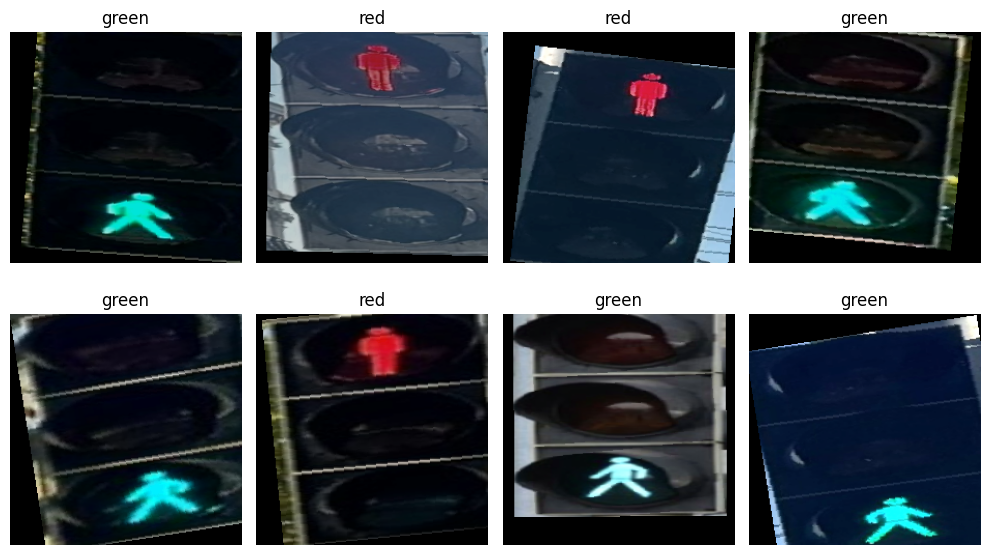

In [11]:
# Quick sanity check: visualize a batch
%matplotlib inline
batch = next(iter(train_loader))
imgs, labels = batch
grid = imgs[:8]

fig = plt.figure(figsize=(10, 6))
for i in range(len(grid)):
    plt.subplot(2, 4, i+1)
    # unnormalize
    img = grid[i].permute(1,2,0).cpu().numpy()
    img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(train_ds.classes[labels[i].item()])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# Create SWIN model
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=len(train_ds.classes))
model.to(device)

# Loss — use Weighted CrossEntropy if classes are imbalanced
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer & Scheduler
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# AMP scaler
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/tmp/ipython-input-1107786614.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [15]:
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Device type für autocast ermitteln
    device_type = "cuda" if device.type == "cuda" else "cpu"

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device_type, enabled=(device_type == "cuda")):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # Metrics
    accm = MulticlassAccuracy(num_classes=len(train_ds.classes)).to(device)
    precm = MulticlassPrecision(num_classes=len(train_ds.classes), average='macro').to(device)
    recallm = MulticlassRecall(num_classes=len(train_ds.classes), average='macro').to(device)
    f1m = MulticlassF1Score(num_classes=len(train_ds.classes), average='macro').to(device)

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

        accm.update(preds, labels)
        precm.update(preds, labels)
        recallm.update(preds, labels)
        f1m.update(preds, labels)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    metrics = {
        "acc": accm.compute().item(),
        "precision_macro": precm.compute().item(),
        "recall_macro": recallm.compute().item(),
        "f1_macro": f1m.compute().item(),
    }
    return epoch_loss, epoch_acc, metrics


best_val_acc = 0.0
patience = 7
bad_epochs = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc, metrics = evaluate(val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"Val f1(macro) {metrics['f1_macro']:.4f} | "
          f"time {(time.time()-t0):.1f}s")

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"model": model.state_dict(),
                    "classes": train_ds.classes,
                    "model_name": MODEL_NAME,
                    "img_size": IMG_SIZE},
                   RUN_DIR / "best_swin.pth")
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print(f"Early stopping at epoch {epoch} (no val acc improvement in {patience} epochs).")
        break

print("Best val acc:", best_val_acc)


Epoch 01/25 | Train loss 1.1745 acc 0.3721 | Val loss 0.9589 acc 0.5000 | Val f1(macro) 0.2222 | time 43.4s
Epoch 02/25 | Train loss 0.8600 acc 0.4419 | Val loss 0.8027 acc 0.6000 | Val f1(macro) 0.6127 | time 36.1s
Epoch 03/25 | Train loss 0.5431 acc 0.9070 | Val loss 0.2520 acc 0.9000 | Val f1(macro) 0.8413 | time 39.1s
Epoch 04/25 | Train loss 0.1130 acc 0.9535 | Val loss 0.0021 acc 1.0000 | Val f1(macro) 1.0000 | time 37.3s
Epoch 05/25 | Train loss 0.0026 acc 1.0000 | Val loss 0.0007 acc 1.0000 | Val f1(macro) 1.0000 | time 36.1s
Epoch 06/25 | Train loss 0.0061 acc 1.0000 | Val loss 0.0001 acc 1.0000 | Val f1(macro) 1.0000 | time 36.8s
Epoch 07/25 | Train loss 0.0002 acc 1.0000 | Val loss 0.0000 acc 1.0000 | Val f1(macro) 1.0000 | time 37.1s
Epoch 08/25 | Train loss 0.2003 acc 0.9535 | Val loss 0.0000 acc 1.0000 | Val f1(macro) 1.0000 | time 35.9s
Epoch 09/25 | Train loss 0.0600 acc 0.9767 | Val loss 0.0391 acc 1.0000 | Val f1(macro) 1.0000 | time 38.7s
Epoch 10/25 | Train loss 0.0

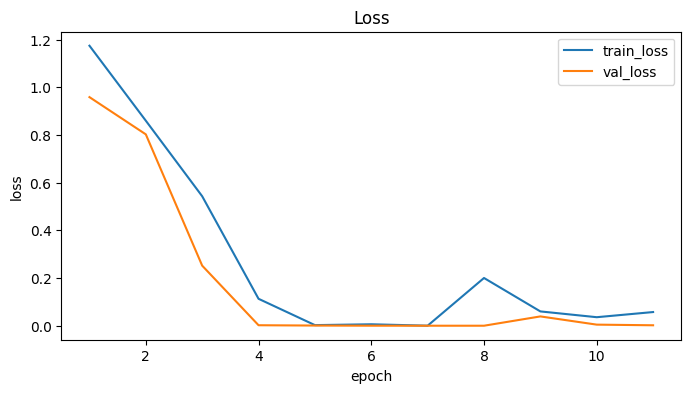

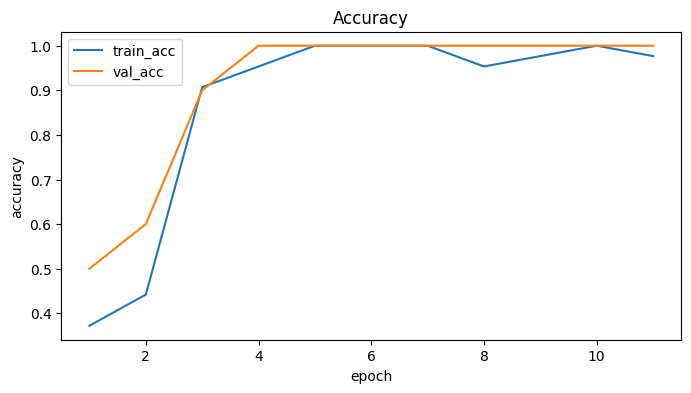

In [16]:
# Plot training curves
epochs_ran = len(history["train_loss"])
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs_ran+1), history["train_loss"], label="train_loss")
plt.plot(range(1, epochs_ran+1), history["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss"); plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1, epochs_ran+1), history["train_acc"], label="train_acc")
plt.plot(range(1, epochs_ran+1), history["val_acc"], label="val_acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Accuracy"); plt.show()

Confusion matrix (rows=true, cols=pred):
 [[3 0 0]
 [0 5 0]
 [0 0 2]]


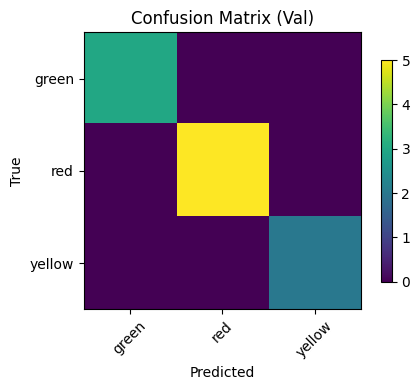

In [17]:
# Confusion matrix on validation set
@torch.no_grad()
def confusion_matrix(loader):
    model.eval()
    cm_metric = MulticlassConfusionMatrix(num_classes=len(train_ds.classes)).to(device)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        cm_metric.update(preds, labels)
    return cm_metric.compute().cpu().numpy()

cm = confusion_matrix(val_loader)
print("Confusion matrix (rows=true, cols=pred):\n", cm)

# Simple visualization
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.xticks(range(len(train_ds.classes)), train_ds.classes, rotation=45)
plt.yticks(range(len(train_ds.classes)), train_ds.classes)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Val)")
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.show()

In [18]:
# Optional: evaluation on test set if present
if test_loader is not None:
    test_loss, test_acc, test_metrics = evaluate(test_loader)
    print(f"Test loss {test_loss:.4f} acc {test_acc:.4f} "
          f"| f1(macro) {test_metrics['f1_macro']:.4f} "
          f"| precision(macro) {test_metrics['precision_macro']:.4f} "
          f"| recall(macro) {test_metrics['recall_macro']:.4f}")
else:
    print("No test/ folder provided — skipping test evaluation.")

NameError: name 'test_loader' is not defined

In [19]:
# Inference helper: load best checkpoint and classify a single image
from PIL import Image

def load_best_model(checkpoint_path=RUN_DIR/"best_swin.pth"):
    ckpt = torch.load(checkpoint_path, map_location=device)
    classes = ckpt["classes"]
    mname = ckpt.get("model_name", MODEL_NAME)
    img_size = ckpt.get("img_size", IMG_SIZE)

    mdl = timm.create_model(mname, pretrained=False, num_classes=len(classes))
    mdl.load_state_dict(ckpt["model"])
    mdl.to(device)
    mdl.eval()

    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    return mdl, classes, tfm

@torch.no_grad()
def predict_image(img_path, model=None, classes=None, tfm=None):
    if model is None:
        model, classes, tfm = load_best_model()

    img = Image.open(img_path).convert("RGB")
    x = tfm(img).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    return {
        "pred_class": classes[pred_idx],
        "probs": {classes[i]: float(probs[i]) for i in range(len(classes))}
    }


In [27]:
# Example (update the path):
res = predict_image("/content/drive/MyDrive/Computer_Vision_Project/data/cropped_images/val/red/IMG_0006_jpeg.rf.6fce363a7be7799eb7209304a978c5cb.jpg")
print(res)


{'pred_class': 'red', 'probs': {'green': 8.50118169637426e-07, 'red': 0.9999918937683105, 'yellow': 7.238501893880311e-06}}
